In [55]:
import pandas as pd

df=pd.read_csv('../datasets/processed/DSGP1.csv')
df.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,Cluster_Label,PCACOMP1,PCACOMP2,PCACOMP3
0,24.166667,6.551333,77.967333,0.587333,1,-1.780082,-0.433574,-1.627375
1,24.581667,5.710000,79.531667,0.565000,1,-1.479069,-0.312703,-0.859869
2,24.756000,6.982000,80.534000,0.611000,1,-1.336950,-0.412495,-0.381413
3,25.878333,8.392500,71.654167,0.480000,0,-1.730179,-0.101366,-1.368670
4,27.590000,7.645000,72.365000,0.433333,0,-1.080854,-0.187889,0.928905


In [56]:
from sklearn.model_selection import GridSearchCV, train_test_split,StratifiedKFold,cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from imblearn.combine import SMOTETomek
from sklearn.metrics import accuracy_score
from collections import Counter


X = df.drop(["Cluster_Label"], axis=1)
Y = df["Cluster_Label"]

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42,stratify=Y)


smote_tomek = SMOTETomek(random_state=42)
X_train_resampled, y_train_resampled = smote_tomek.fit_resample(X_train, y_train)
print("Class distribution after SMOTETomek:", Counter(y_train_resampled))


rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 250, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [10, 15, 20],
    'min_samples_leaf': [5, 10, 15],
    'max_features': ['sqrt', 'log2'],
}


grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, 
                           cv=5, n_jobs=-1, verbose=2, scoring='accuracy')

grid_search.fit(X_train_resampled, y_train_resampled)


print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train_resampled)
y_val_pred = best_model.predict(X_test)

training_accuracy = accuracy_score(y_train_resampled, y_train_pred)
testing_accuracy = accuracy_score(y_test, y_val_pred)

print(f"Training Accuracy: {training_accuracy * 100:.2f}%")
print(f"Validation Accuracy: {testing_accuracy * 100:.2f}%")


Class distribution after SMOTETomek: Counter({0: 396, 1: 396})
Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 10, 'n_estimators': 200}
Training Accuracy: 99.12%
Validation Accuracy: 97.41%


In [57]:
X.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,24.166667,6.551333,77.967333,0.587333,-1.780082,-0.433574,-1.627375
1,24.581667,5.710000,79.531667,0.565000,-1.479069,-0.312703,-0.859869
2,24.756000,6.982000,80.534000,0.611000,-1.336950,-0.412495,-0.381413
3,25.878333,8.392500,71.654167,0.480000,-1.730179,-0.101366,-1.368670
4,27.590000,7.645000,72.365000,0.433333,-1.080854,-0.187889,0.928905


In [58]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_val_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97        94
           1       0.97      0.98      0.97        99

    accuracy                           0.97       193
   macro avg       0.97      0.97      0.97       193
weighted avg       0.97      0.97      0.97       193



[[91  3]
 [ 2 97]]


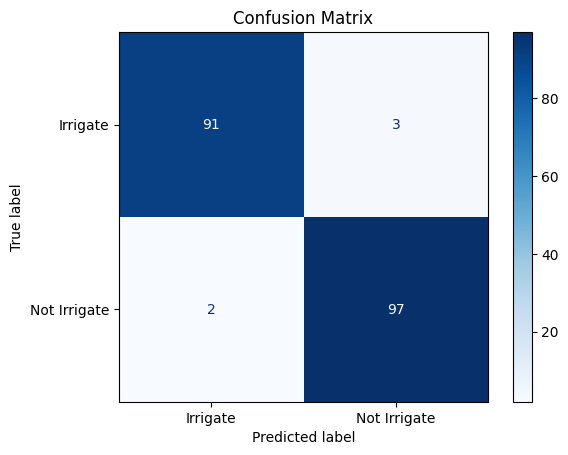

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
print(confusion_matrix(y_test, y_val_pred))
labels = ["Irrigate", "Not Irrigate"]
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_val_pred),display_labels=labels)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

In [60]:
import numpy as np

193


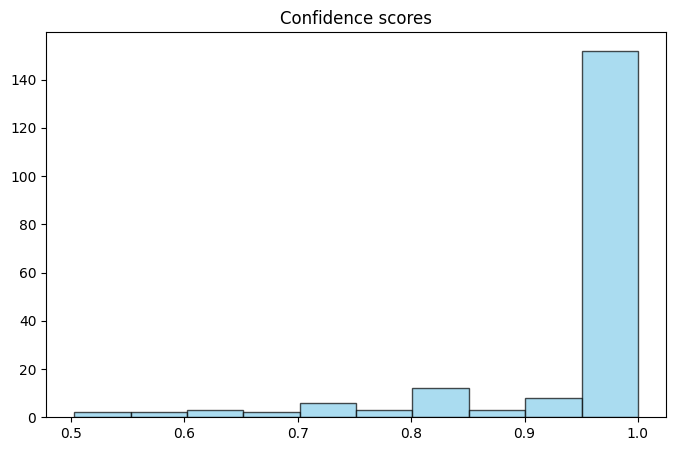

In [61]:
predicted_probablity=best_model.predict_proba(X_test)
predict_class=np.argmax(predicted_probablity)
confidence=[]
for val in predicted_probablity:
    confidence.append(np.max(val))
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.hist(confidence, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Confidence scores')
print(len(confidence))

In [62]:
list_threshold=[]
for i in range(5,20,5):
    threshold=np.percentile(confidence,i)
    print(f'{i}th percentile: {threshold}')
    list_threshold.append(threshold)


5th percentile: 0.7148901067886363
10th percentile: 0.814577531562005
15th percentile: 0.8442000231192957


0.6451686646686647
0.525762153695977
0.5030002246205809
0.5770428370648959
0.5554679267241185
0.6851754071092307
0.6234486790986792
0.6921745248215834
0.7067016863855099
0.6426451437451436
10


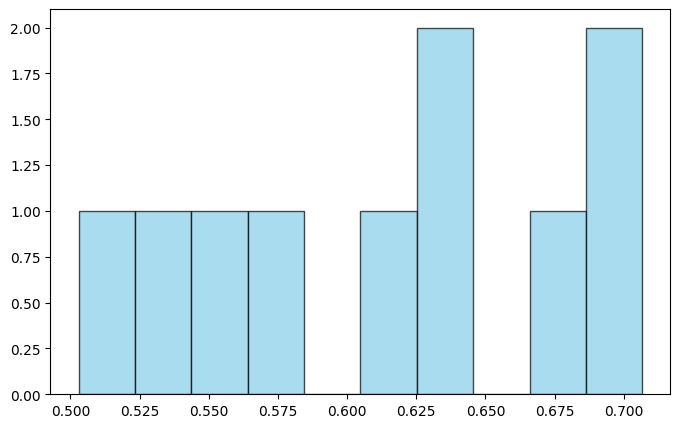

In [63]:

lowones5th=[]
for values in confidence:
    if values<0.71:
        print(values)
        lowones5th.append(values)

plt.figure(figsize=(8, 5))
plt.hist(lowones5th, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
print(len(lowones5th))

0.740276564530241
0.7440496227628581
0.6451686646686647
0.525762153695977
0.5030002246205809
0.8029276718293745
0.7203490537240538
0.5770428370648959
0.5554679267241185
0.6851754071092307
0.6234486790986792
0.7303634551722787
0.6921745248215834
0.7718550199800199
0.7067016863855099
0.6426451437451436
0.7387949338243454
0.7872207126207127
0.7770942529692527
19


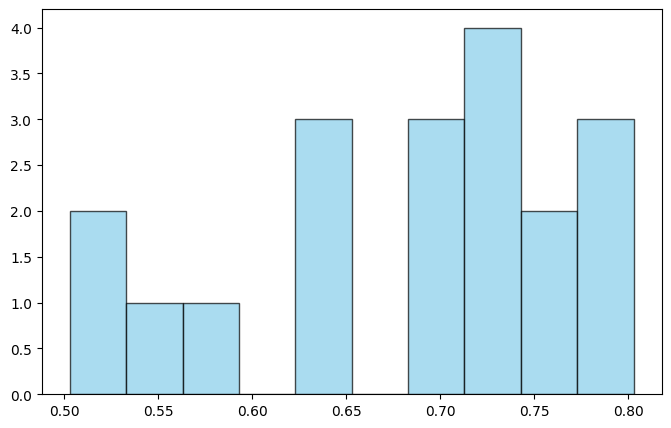

In [64]:

lowones10th=[]
for values in confidence:
    if values<0.81:
        print(values)
        lowones10th.append(values)

plt.figure(figsize=(8, 5))
plt.hist(lowones10th, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
print(len(lowones10th))

0.740276564530241
0.8196238761238759
0.7440496227628581
0.8287358030858029
0.6451686646686647
0.525762153695977
0.5030002246205809
0.8029276718293745
0.7203490537240538
0.5770428370648959
0.5554679267241185
0.6851754071092307
0.6234486790986792
0.7303634551722787
0.6921745248215834
0.7718550199800199
0.8144012931512928
0.8232731137756288
0.8152824852048535
0.7067016863855099
0.6426451437451436
0.8303577312565316
0.7387949338243454
0.8312216394716393
0.7872207126207127
0.7770942529692527
0.8281363775113771
0.8207976869621608
28


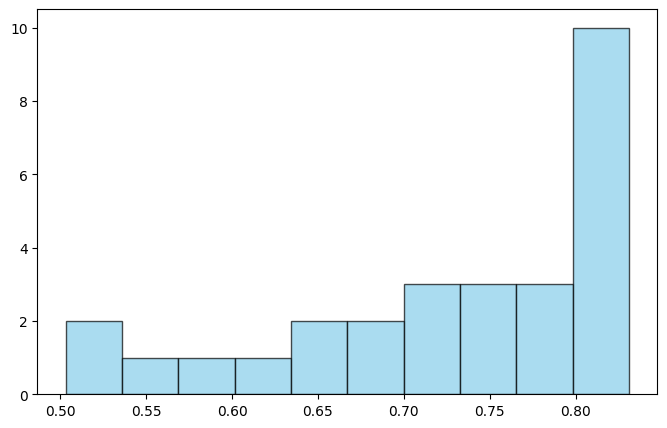

In [65]:

lowones15th=[]
for values in confidence:
    if values<0.84:
        print(values)
        lowones15th.append(values)

plt.figure(figsize=(8, 5))
plt.hist(lowones15th, bins=10, color='skyblue', edgecolor='black', alpha=0.7)
print(len(lowones15th))

In [66]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier()
scores = cross_val_score(rf_classifier, X, Y, cv=5, scoring='f1_macro')
print("Cross-Validation F1-Scores:", scores)
print("Mean F1-Score:", scores.mean())

Cross-Validation F1-Scores: [0.95849462 0.97927405 0.9792696  0.98962366 0.98444092]
Mean F1-Score: 0.9782205716628083


In [67]:
from sklearn.preprocessing import StandardScaler



X=df.drop(['Cluster_Label'],axis=1)

scaler=StandardScaler()
X_scale=scaler.fit_transform(X)
Scaled_df=pd.DataFrame(X_scale,columns=X.columns)
Scaled_df.head()

,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,-1.792869,-0.070642,-0.015286,0.051606,-1.780082,-0.433574,-1.627375
1,-1.506076,-0.484933,0.185296,-0.073296,-1.479069,-0.312703,-0.859869
2,-1.385600,0.141427,0.313818,0.183966,-1.336950,-0.412495,-0.381413
3,-0.609990,0.835988,-0.824773,-0.548671,-1.730179,-0.101366,-1.368670
4,0.572889,0.467903,-0.733629,-0.809661,-1.080854,-0.187889,0.928905


In [68]:
df1 = pd.concat([df['Cluster_Label'], Scaled_df], axis=1)
df1.head()

,Cluster_Label,T2M,T2M_RANGE,RH2M,GWETTOP,PCACOMP1,PCACOMP2,PCACOMP3
0,1,-1.792869,-0.070642,-0.015286,0.051606,-1.780082,-0.433574,-1.627375
1,1,-1.506076,-0.484933,0.185296,-0.073296,-1.479069,-0.312703,-0.859869
2,1,-1.385600,0.141427,0.313818,0.183966,-1.336950,-0.412495,-0.381413
3,0,-0.609990,0.835988,-0.824773,-0.548671,-1.730179,-0.101366,-1.368670
4,0,0.572889,0.467903,-0.733629,-0.809661,-1.080854,-0.187889,0.928905


In [69]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train_resampled, y_train_resampled)

y_pred = dt_model.predict(X_test)
y_train_pred=dt_model.predict(X_train_resampled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("training accuracy:", accuracy_score(y_train_resampled,y_train_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9740932642487047
training accuracy: 0.9962121212121212
              precision    recall  f1-score   support

           0       0.99      0.96      0.97        94
           1       0.96      0.99      0.98        99

    accuracy                           0.97       193
   macro avg       0.97      0.97      0.97       193
weighted avg       0.97      0.97      0.97       193



In [70]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[90  4]
 [ 1 98]]


In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Flatten,Input
from sklearn.model_selection import train_test_split

X=df1.drop('Cluster_Label',axis=1)
Y=df1['Cluster_Label']

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
X_resampled, y_resampled = smote_tomek.fit_resample(X_train, y_train)


model = Sequential([
    Input(shape=(7,)),
    Dense(32, activation='relu'),
    Dropout(0.4),
    Dense(16, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])


model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(X_resampled, y_resampled, validation_data=(X_test, y_test), epochs=30, batch_size=64)

Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5915 - loss: 0.6508 - val_accuracy: 0.8342 - val_loss: 0.5704
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7143 - loss: 0.5428 - val_accuracy: 0.9067 - val_loss: 0.4964
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8086 - loss: 0.4876 - val_accuracy: 0.9482 - val_loss: 0.4338
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8826 - loss: 0.4160 - val_accuracy: 0.9430 - val_loss: 0.3775
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8878 - loss: 0.3695 - val_accuracy: 0.9482 - val_loss: 0.3276
Epoch 6/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9204 - loss: 0.3199 - val_accuracy: 0.9585 - val_loss: 0.2827
Epoch 7/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9392 - loss: 0.2788 - val_accuracy: 0.9741 - val_loss: 0.2434
Epoch 8/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9317 - loss: 0.2495 - val_accuracy: 0.9741 - v

In [72]:
from sklearn.metrics import classification_report
import numpy as np

y_pred=model.predict(X_test)
y_train_pred=model.predict(X_resampled)
y_train_pred_labels = (y_train_pred > 0.5).astype(int)
y_pred_labels = (y_pred > 0.5).astype(int)
print("Training accuracy",accuracy_score(y_resampled,y_train_pred_labels))
print("Testing accuracy",accuracy_score(y_test,y_pred_labels))  
print(classification_report(y_test, y_pred_labels))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training accuracy 0.9947916666666666
Testing accuracy 0.9896373056994818
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        80
           1       1.00      0.98      0.99       113

    accuracy                           0.99       193
   macro avg       0.99      0.99      0.99       193
weighted avg       0.99      0.99      0.99       193



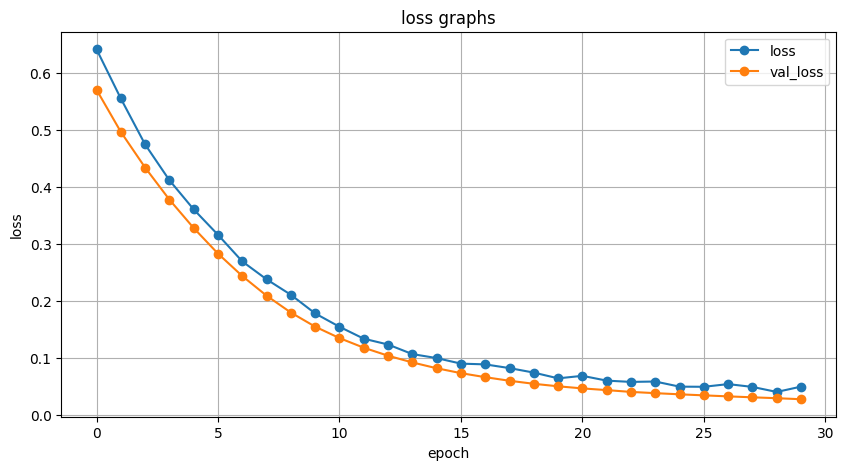

In [73]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='loss', marker='o')
plt.plot(history.history['val_loss'], label='val_loss',marker='o')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title("loss graphs")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
import pickle
with open('irrigation_optimization_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)